# MMM Modeling Walkthrough — EDA, Failure Modes & Recovery

Marketing-mix modeling is **iterative**. You do not get the answer from the first
fit; exploratory analysis, causal reasoning, diagnostics, and experiments drive
successive revisions. This notebook walks through that loop on **realistic, messy
data** — many candidate drivers, confounded spend, weak and collinear channels,
low signal-to-noise — and is interactive: **run every cell and change things.**

It has two parts:

1. **EDA before you model** — the practical checks that tell you, *before* fitting,
   which channels are identifiable, which controls are valid, and where the model
   will struggle.
2. **Modeling: failure modes & recovery** — the documented 9-step scientific
   workflow, shown as three iterations (naive → causal structure → calibration),
   each fit live and graded against the **known** truth (the data is synthetic, so
   we can check what the model recovers).

> Companion docs: `technical-docs/mmm-modeling-walkthrough.md` (the written
> version), `technical-docs/mmm-robustness-report.md` (convergence / fit-time /
> failure modes), and `tests/synth/README.md`.

In [1]:
import sys, pathlib, warnings, logging
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
for _name in ("pymc", "numpyro", "jax", "arviz", "pytensor"):  # quiet the samplers
    logging.getLogger(_name).setLevel(logging.ERROR)
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root (run from nbs/)

import contextlib, os
@contextlib.contextmanager
def quiet():
    "Hide the samplers' progress bars / chatter; our own prints stay visible."
    with open(os.devnull, "w") as _dn, contextlib.redirect_stdout(_dn), \
            contextlib.redirect_stderr(_dn):
        yield
from tests.synth import dgp  # the realistic synthetic world (ground truth known)

plt.rcParams.update({
    "figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})
INK, ACCENT, SKY, BERRY, LEAF, AMBER, MUTED = (
    "#2b2118", "#b5651d", "#3b6ea5", "#a63a50", "#3f7d5e", "#d98a2b", "#8a8079")
PAL = {"TV": ACCENT, "Search": SKY, "Social": BERRY, "Display": LEAF,
       "Video": AMBER, "Radio": MUTED, "Print": "#c8a26a"}

sc = dgp.make_realistic(seed=42)
weeks, spend, y, controls = sc.weeks, sc.spend, sc.y, sc.controls
print(f"{len(sc.channels)} media channels: {sc.channels}")
print(f"{len(controls.columns)} candidate controls: {list(controls.columns)}")
print(f"{len(y)} weekly observations")
spend.describe().round(1)

7 media channels: ['TV', 'Search', 'Social', 'Display', 'Video', 'Radio', 'Print']
13 candidate controls: ['category_demand', 'distribution', 'price', 'competitor_promo', 'weather', 'holiday', 'brand_awareness', 'noise_1', 'noise_2', 'noise_3', 'noise_4', 'noise_5', 'noise_6']
156 weekly observations


,TV,Search,Social,Display,Video,Radio,Print
count,156.0,156.0,156.0,156.0,156.0,156.0,156.0
mean,72.2,50.2,39.7,32.3,27.5,20.7,13.3
std,82.8,67.1,37.9,30.4,26.1,19.3,12.5
min,1.6,0.9,5.2,4.7,4.1,2.7,1.8
25%,16.9,9.5,11.2,9.4,7.9,5.5,3.6
50%,34.7,21.0,17.8,13.7,10.4,9.1,6.1
75%,107.5,65.8,65.1,48.4,50.4,35.8,23.0
max,448.8,350.3,183.4,132.0,111.6,72.0,46.4


---
# Part 1 — EDA before you model

For MMM, EDA is **not** mainly about the KPI. It is about two questions that
decide whether the model can possibly succeed:

1. **Is each channel identifiable?** (Does its spend vary enough, and
   independently enough, for the data to estimate an effect?)
2. **Are the controls causally valid?** (Which are confounders you *must* keep,
   which are post-treatment "bad controls" you *must* drop?)

Six checks below answer those, followed by a pre-modeling checklist.

## 1.1 — Look at the KPI (level, trend, seasonality, anomalies)

First orient: what is the outcome's scale, does it trend, is it seasonal, are
there obvious anomalies (promotions, stockouts, COVID-style breaks)? These decide
your trend/seasonality spec and warn of structural breaks the model won't handle.

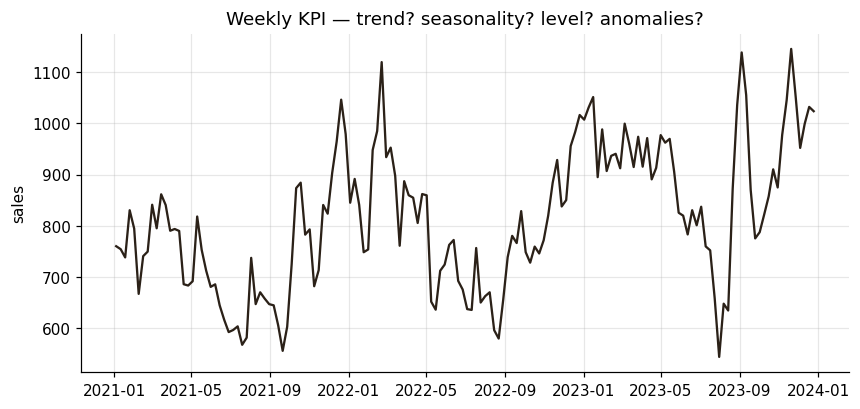

KPI: mean=814  std=137  min=544  max=1145


In [2]:
fig, ax = plt.subplots()
ax.plot(weeks, y, color=INK, lw=1.5)
ax.set(title="Weekly KPI — trend? seasonality? level? anomalies?", ylabel="sales")
plt.show()
print(f"KPI: mean={y.mean():.0f}  std={y.std():.0f}  min={y.min():.0f}  max={y.max():.0f}")

**What to look for:** a clear upward trend (→ include a trend term), an annual
cycle (→ Fourier seasonality), and any spikes/level-shifts. A sharp break (a
COVID-style shift) is *not* something a constant-coefficient MMM handles — flag
it for a dummy or a piecewise trend, or it will leak into media. Here: mild trend
+ yearly seasonality, no breaks.

## 1.2 — Spend variation = identifiability

A coefficient can only be estimated if its driver **varies**. An always-on
channel with near-constant spend is *confounded with the intercept* — the model
cannot tell its effect from the baseline, no matter how much data you have. The
coefficient of variation (CoV = std/mean) is the quick screen.

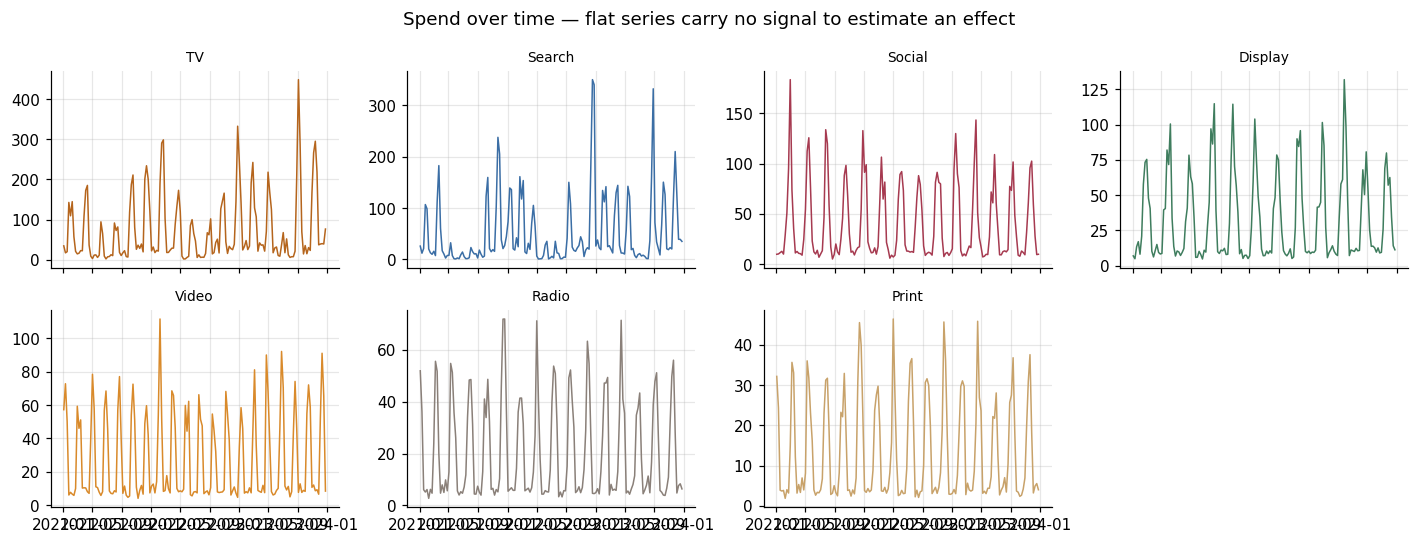

,CoV (std/mean)
Radio,0.93
Print,0.93
Display,0.94
Video,0.95
Social,0.95
TV,1.15
Search,1.34


⚠ Low-variation (CoV < 0.3), hard to identify observationally: []


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5), sharex=True)
for ax, c in zip(axes.ravel(), sc.channels):
    ax.plot(weeks, spend[c], color=PAL[c], lw=1); ax.set_title(c, fontsize=9)
axes.ravel()[-1].axis("off")
fig.suptitle("Spend over time — flat series carry no signal to estimate an effect")
plt.tight_layout(); plt.show()

cov = (spend.std() / spend.mean()).sort_values()
display(cov.round(2).to_frame("CoV (std/mean)"))
low = cov[cov < 0.3].index.tolist()
print(f"⚠ Low-variation (CoV < 0.3), hard to identify observationally: {low}")

**Rule of thumb:** CoV below ~0.3 means the channel is nearly always-on — expect
a wide, prior-dominated coefficient no matter what. **Radio and Print** are flat
here. The fix is not a modeling trick; it's an **experiment** (Part 2, v3) or
accepting you can only report a wide interval.

## 1.3 — Collinearity: which channels can't be separated

If two channels always move together (same flighting calendar, bundled buys), the
data identifies their **combined** effect but not the split — the individual
coefficients trade off and become unstable. Check the spend correlation matrix and
the variance-inflation factor (VIF).

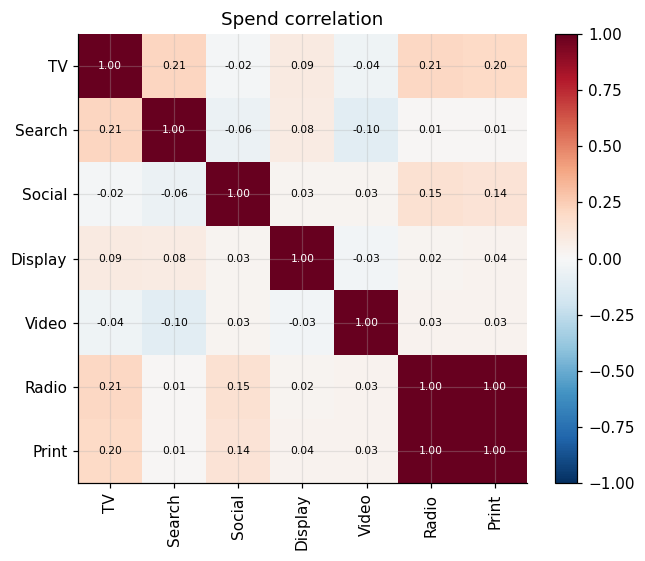

⚠ Near-collinear pairs (|corr| > 0.9): [('Radio', 'Print', np.float64(1.0))]


,VIF (>10 ⇒ problematic)
TV,1.1
Search,1.1
Social,1.1
Display,1.0
Video,1.0
Radio,124.7
Print,123.7


In [4]:
corr = spend.corr()
fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for (i, j), v in np.ndenumerate(corr.values):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
            color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, fraction=0.046); ax.set_title("Spend correlation"); plt.tight_layout(); plt.show()

cols = spend.columns
pairs = [(a, b, round(corr.loc[a, b], 2)) for i, a in enumerate(cols)
         for b in cols[i + 1:] if abs(corr.loc[a, b]) > 0.9]
print("⚠ Near-collinear pairs (|corr| > 0.9):", pairs)

Xs = (spend - spend.mean()) / spend.std()
vif = pd.Series(np.diag(np.linalg.inv(Xs.corr().values)), index=cols)
display(vif.round(1).to_frame("VIF (>10 ⇒ problematic)"))

**What to look for:** any pair near ±1, or VIF > 10. **Radio and Print** are
near-perfectly collinear (bought together). Options: model them as **one grouped
channel**, or **anchor one with an experiment** so the split is identified
(Part 2, v3). Reporting separate point ROIs for collinear channels is a trap.

## 1.4 — Outliers & spikes (the normalization trap)

The model normalizes each channel by its **training max**. A single data-entry
spike or one-off mega-campaign sets that max and compresses every normal week into
a tiny sliver of the response curve — quietly attenuating the channel. Screen for
spikes before they bite.

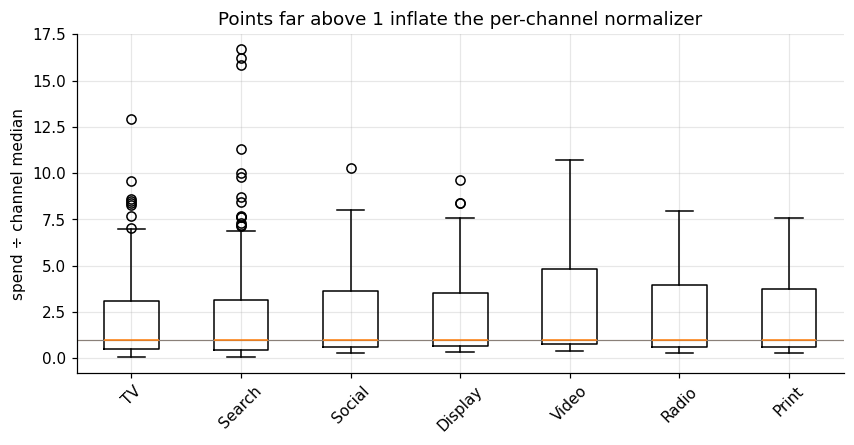

⚠ Channels with a max ≫ median (potential data-entry spikes): {'TV': 12.9, 'Search': 16.7, 'Social': 10.3, 'Display': 9.6, 'Video': 10.7}


In [5]:
ratio = spend / spend.median()
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([ratio[c] for c in sc.channels], labels=sc.channels, showfliers=True)
ax.axhline(1, color=MUTED, lw=0.8); ax.set(ylabel="spend ÷ channel median",
    title="Points far above 1 inflate the per-channel normalizer")
plt.xticks(rotation=45); plt.show()
spikes = {c: round(spend[c].max() / spend[c].median(), 1) for c in sc.channels
          if spend[c].max() > 8 * spend[c].median()}
print("⚠ Channels with a max ≫ median (potential data-entry spikes):", spikes or "none")

**What to look for:** a max more than ~8–10× the median. There are none in this
dataset, but in real data this is common (a mis-keyed value, a one-week launch
burst). Recovery: verify the value, then **cap/winsorize** or normalize by a high
percentile instead of the raw max. (See the `spend_outliers` silent failure in
the robustness report — 0% interval coverage when this is ignored.)

## 1.5 — Exogeneity: is spend driven by demand? (confounding)

The deadliest MMM bias: a hidden demand signal drives **both** spend (teams bid
harder when demand is high) **and** sales. Then `corr(spend, sales)` is mostly
demand, not media effect. Screen by correlating each channel's spend with any
demand proxy you have (a category index, your own targeting rules, seasonality).

,"corr(spend, demand)","corr(spend, sales) — NOT roi"
TV,0.53,0.57
Search,0.48,0.46
Radio,0.17,0.25
Print,0.16,0.24
Display,0.04,0.12
Social,0.02,0.17
Video,-0.07,0.14


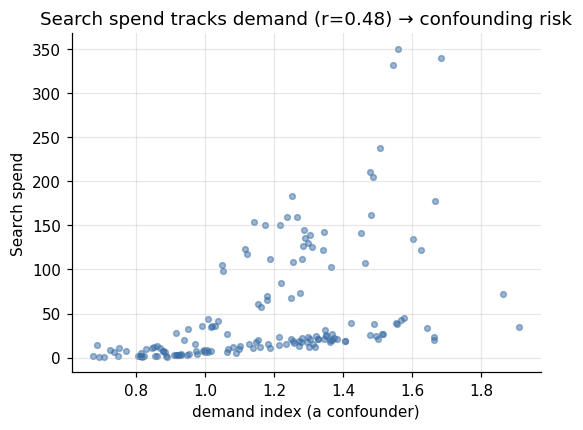

In [6]:
# In real life: a category-demand index, Google Trends, or your pacing rules.
demand = sc.notes["latent_demand"]
sd = pd.Series({c: np.corrcoef(spend[c], demand)[0, 1] for c in sc.channels})
naive = pd.Series({c: np.corrcoef(spend[c], y)[0, 1] for c in sc.channels})
display(pd.DataFrame({"corr(spend, demand)": sd, "corr(spend, sales) — NOT roi": naive})
        .round(2).sort_values("corr(spend, demand)", ascending=False))

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.scatter(demand, spend["Search"], s=14, alpha=0.5, color=SKY)
ax.set(xlabel="demand index (a confounder)", ylabel="Search spend",
       title=f"Search spend tracks demand (r={sd['Search']:.2f}) → confounding risk")
plt.show()

**What to look for:** any channel whose spend correlates with a demand driver is
**not exogenous** — its naive `corr(spend, sales)` over-states it. **TV and
Search** chase demand here. Recovery: you **must include the demand proxy as a
control** (and not shrink it — Part 2, v2). If you have no proxy at all, that
channel's observational ROI is unidentifiable and needs an experiment.
**Never read `corr(spend, sales)` as ROI** — that column is the trap.

## 1.6 — Classify the candidate controls (build the DAG)

The single highest-leverage EDA step. For each candidate control, ask how it
relates to **spend** and to the **KPI** — that tells you its causal role and how
to treat it:

| pattern | role | treatment |
|---|---|---|
| correlates with **both** spend & KPI | **confounder** | **must include, do NOT shrink** |
| correlates with KPI, not spend | precision control | include (regularize) |
| is **downstream of media** (media drives it) | **mediator / bad control** | **must EXCLUDE** |
| correlates with neither | irrelevant | harmless; the prior shrinks it |

In [7]:
rows = []
for col in controls.columns:
    cs = max(abs(np.corrcoef(controls[col], spend[c])[0, 1]) for c in sc.channels)
    cy = abs(np.corrcoef(controls[col], y)[0, 1])
    # a control that media *predicts* is a red flag for a mediator (post-treatment)
    downstream = max(abs(np.corrcoef(controls[col], spend[c])[0, 1]) for c in ["TV", "Video"])
    rows.append((col, round(cs, 2), round(cy, 2), round(downstream, 2)))
tab = pd.DataFrame(rows, columns=["control", "max|corr spend|", "|corr KPI|", "corr w/ TV+Video"])
display(tab.sort_values("|corr KPI|", ascending=False).reset_index(drop=True))

print("Answer key (how this world was actually generated):")
print(sc.notes["roles"])

,control,max|corr spend|,|corr KPI|,corr w/ TV+Video
0,category_demand,0.51,0.78,0.51
1,distribution,0.29,0.69,0.23
2,brand_awareness,0.56,0.57,0.56
3,noise_6,0.14,0.43,0.14
4,price,0.24,0.42,0.17
5,weather,0.08,0.39,0.08
6,noise_5,0.10,0.37,0.09
7,noise_3,0.16,0.31,0.12
8,competitor_promo,0.07,0.22,0.05
9,noise_4,0.05,0.19,0.05


Answer key (how this world was actually generated):
{'category_demand': 'confounder', 'distribution': 'confounder', 'price': 'precision', 'competitor_promo': 'precision', 'weather': 'precision', 'holiday': 'precision', 'noise_1': 'irrelevant', 'noise_2': 'irrelevant', 'noise_3': 'irrelevant', 'noise_4': 'irrelevant', 'noise_5': 'irrelevant', 'noise_6': 'irrelevant', 'brand_awareness': 'mediator'}


**Reading the table:** `category_demand` and `distribution` correlate with both
spend and KPI → **confounders**. `price/competitor/weather/holiday` relate to the
KPI → **precision controls**. `brand_awareness` is strongly predicted by TV/Video
— that's the tell of a **mediator** (media → awareness → sales): including it
*blocks* the path and under-counts those channels, so it must be **excluded**.
The `noise_*` columns relate to nothing → irrelevant.

This gives the **DAG** — and the DAG *is* the model spec:

```
   category_demand / distribution ──► spend AND sales   (confounders: keep, wide prior)
   TV, Search ──────────────────────► sales             (but chase demand)
   TV, Video ──► brand_awareness ────► sales            (MEDIATOR: exclude — bad control)
   price, competitor, weather, holiday ► sales          (precision: keep, regularized)
   noise_1..6 ──╴(no edge)╶──────────  sales            (irrelevant: prior shrinks them)
   Radio ≈ Print (collinear)                            (needs an experiment to split)
```

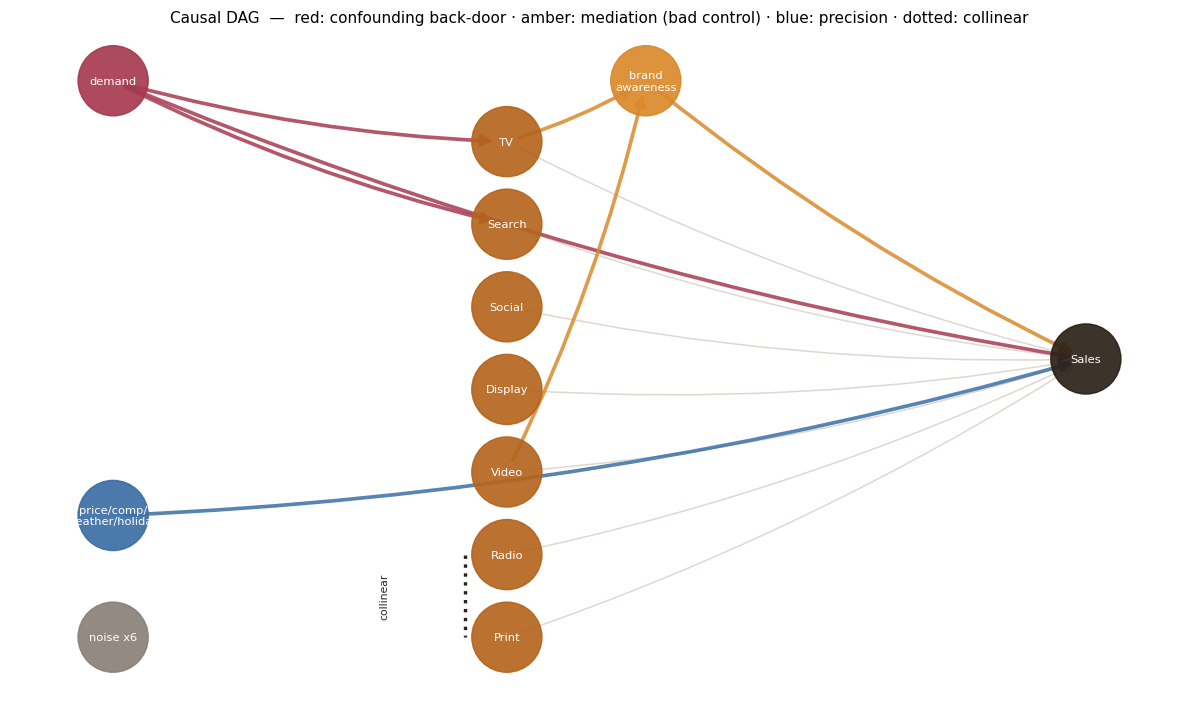

In [8]:
import networkx as nx

roles = sc.notes["roles"]
G = nx.DiGraph()
for m in sc.channels:
    G.add_node(m, kind="media")
G.add_node("Sales", kind="kpi")
G.add_node("demand", kind="confounder")
G.add_node("brand\nawareness", kind="mediator")
G.add_node("price/comp/\nweather/holiday", kind="precision")
G.add_node("noise x6", kind="irrelevant")
for m in sc.channels:
    G.add_edge(m, "Sales", kind="media")
for ch in ["TV", "Search"]:            # the demand back-door
    G.add_edge("demand", ch, kind="confound")
G.add_edge("demand", "Sales", kind="confound")
for ch in ["TV", "Video"]:             # mediation path (bad control)
    G.add_edge(ch, "brand\nawareness", kind="mediate")
G.add_edge("brand\nawareness", "Sales", kind="mediate")
G.add_edge("price/comp/\nweather/holiday", "Sales", kind="precision")

pos = {"demand": (-1.4, 3.4), "brand\nawareness": (0.9, 3.4), "Sales": (2.8, 0.2),
       "price/comp/\nweather/holiday": (-1.4, -1.6), "noise x6": (-1.4, -3.0)}
for i, m in enumerate(sc.channels):
    pos[m] = (0.3, 2.7 - i * 0.95)
nkind = {"media": ACCENT, "kpi": INK, "confounder": BERRY, "mediator": AMBER,
         "precision": SKY, "irrelevant": MUTED}
ekind = {"media": "#d9d2c6", "confound": BERRY, "mediate": AMBER, "precision": SKY}
fig, ax = plt.subplots(figsize=(11, 6.5))
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2100,
                       node_color=[nkind[G.nodes[n]["kind"]] for n in G], alpha=0.92)
for k, col in ekind.items():
    es = [(u, v) for u, v, d in G.edges(data=True) if d["kind"] == k]
    nx.draw_networkx_edges(G, pos, edgelist=es, ax=ax, edge_color=col,
                           width=2.4 if k != "media" else 1.0, alpha=0.85,
                           arrowsize=15, connectionstyle="arc3,rad=0.06")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.5, font_color="white")
ax.plot([pos["Radio"][0]], [pos["Radio"][1]], marker="")  # keep Radio/Print in view
ax.plot([pos["Radio"][0] - 0.18, pos["Print"][0] - 0.18],
        [pos["Radio"][1], pos["Print"][1]], ls=":", color=INK, lw=2.2)
ax.text(pos["Radio"][0] - 0.55, (pos["Radio"][1] + pos["Print"][1]) / 2,
        "collinear", rotation=90, va="center", fontsize=7, color=INK)
ax.set_title("Causal DAG  —  red: confounding back-door · amber: mediation (bad "
             "control) · blue: precision · dotted: collinear", fontsize=10)
ax.axis("off"); plt.tight_layout(); plt.show()

## 1.7 — How hard is this for the model? (it is *not* "simple synthetic data")

It is easy to make synthetic data the model nails — draw it from the model's own
assumptions and recovery is near-perfect. This world is deliberately the
opposite: the structure the model must fight is in the data, not the sampler.

In [9]:
n_factors = len(sc.channels) + len(controls.columns)
n_noise = sum(v == "irrelevant" for v in sc.notes["roles"].values())
media_share = sc.true_contribution.sum() / sc.y.sum()
conf = max(np.corrcoef(spend[c], sc.notes["latent_demand"])[0, 1] for c in ["TV", "Search"])
collin = (spend.corr().where(~np.eye(len(spend.columns), dtype=bool)).abs().max().max())
print(f"Candidate factors to sort out      : {n_factors}  ({len(sc.channels)} media + "
      f"{len(controls.columns)} controls, of which {n_noise} are pure noise)")
print(f"Media as a share of total sales     : ~{media_share:.0%}  "
      "(a small, confounded slice — the rest is baseline/demand/controls)")
print(f"Worst spend–demand confounding (corr): {conf:.2f}   (exogeneity is violated)")
print(f"Worst channel collinearity (corr)    : {collin:.2f}   (a pair the data can't split)")
print()
print("Contrast (same model, from the robustness report):")
print("  • on data drawn from the model's assumptions → ~7% ROI error, 100% CI coverage")
print("  • here, after three iterations → TV still ~36% biased, Radio/Print unidentifiable")
print("  → the gap is the DATA's structure (confounding, identifiability), not a fit problem.")

Candidate factors to sort out      : 20  (7 media + 13 controls, of which 6 are pure noise)
Media as a share of total sales     : ~26%  (a small, confounded slice — the rest is baseline/demand/controls)
Worst spend–demand confounding (corr): 0.53   (exogeneity is violated)
Worst channel collinearity (corr)    : 1.00   (a pair the data can't split)

Contrast (same model, from the robustness report):
  • on data drawn from the model's assumptions → ~7% ROI error, 100% CI coverage
  • here, after three iterations → TV still ~36% biased, Radio/Print unidentifiable
  → the gap is the DATA's structure (confounding, identifiability), not a fit problem.


**Why simple recovery tests mislead.** A model that recovers clean, model-shaped
data tells you the sampler works — nothing more. Real data violates exogeneity
and identifiability, and *those* are what break the ROI. The companion
[robustness report](../technical-docs/mmm-robustness-report.md) quantifies this:
the same model is confidently wrong on five realistic pathologies while every
routine diagnostic stays green.

## Pre-modeling checklist

Before you fit anything:

- [ ] **KPI:** trend, seasonality, scale understood; structural breaks/anomalies flagged.
- [ ] **Identifiability:** every channel's CoV high enough? (flat ⇒ expect prior-dominated; plan an experiment).
- [ ] **Collinearity:** no |corr| > 0.9 / VIF > 10 pairs? (collinear ⇒ group or anchor one).
- [ ] **Outliers:** no spend spike ≫ median distorting normalization? (cap/winsorize).
- [ ] **Exogeneity:** spend not driven by demand? (if it is, the demand proxy is mandatory).
- [ ] **Controls classified:** confounders (keep, don't shrink), precision (keep), mediators/colliders (**drop**), irrelevant (harmless).
- [ ] **Pre-specify** adstock max-lag, saturation, priors, trend/seasonality **now**, before seeing results.

---
# Part 2 — Modeling: failure modes & recovery

Now the iterative loop. We fit three versions, each graded against the known
truth. The helper below builds a model from the scenario (optionally dropping
controls and assigning causal roles), fits it, and grades every channel.

> Fits use a deliberately **fast** config (numpyro, 300 draws × 2 chains) so the
> notebook runs end-to-end in a few minutes. The qualitative arc is stable; for
> production use ≥1000 draws / 4 chains (see the robustness report).

In [10]:
from dataclasses import replace
from mmm_framework.config import (
    CausalControlRole, ControlSelectionConfig, InferenceMethod, ModelConfig,
)
from mmm_framework.model import BayesianMMM, TrendConfig, TrendType

# Importing pymc (above) installs its own log handler, so re-quiet the samplers
# here — and stop propagation so "Sampling: [...]" lines don't reach the notebook.
for _n in ("pymc", "pymc.sampling", "numpyro", "jax", "arviz", "pytensor"):
    _lg = logging.getLogger(_n); _lg.setLevel(logging.ERROR); _lg.propagate = False

DRAWS, CHAINS = 300, 2

def build_model(scenario, *, drop=(), roles=None, target_accept=0.9, selection="none"):
    sub = scenario.controls.drop(columns=list(drop)) if drop else scenario.controls
    variant = replace(scenario, controls=sub, control_roles=roles)
    cfg = ModelConfig(
        inference_method=InferenceMethod.BAYESIAN_NUMPYRO,
        n_chains=CHAINS, n_draws=DRAWS, n_tune=DRAWS,
        target_accept=target_accept, use_parametric_adstock=True, optim_seed=0,
        control_selection=ControlSelectionConfig(method=selection, expected_nonzero=4),
    )
    return variant, BayesianMMM(variant.panel(), cfg, TrendConfig(type=TrendType.LINEAR))

def grade(variant, model, fit, *, prior_samples=400):
    "Per-channel: estimate vs known truth, 90% CI coverage, beta SD, learning verdict."
    with quiet():
        contrib = model.compute_counterfactual_contributions(
            compute_uncertainty=True, hdi_prob=0.9, random_seed=0)
        learn = model.compute_parameter_learning(prior_samples=prior_samples)
    verdict = {p[5:]: v for p, v in zip(learn["parameter"], learn["verdict"])
               if p.startswith("beta_") and not p.startswith("beta_controls")}
    post = fit.trace.posterior
    rows = []
    for c in variant.channels:
        t = float(variant.true_contribution[c]); e = float(contrib.total_contributions[c])
        lo = float(contrib.contribution_hdi_low[c]); hi = float(contrib.contribution_hdi_high[c])
        rows.append({
            "channel": c, "true": round(t), "est": round(e),
            "err": f"{(e - t) / t:+.0%}", "in 90% CI": "✓" if lo <= t <= hi else "✗",
            "rel_CI_width": round((hi - lo) / abs(e), 1),
            "beta_sd": round(float(post[f"beta_{c}"].std()), 2) if f"beta_{c}" in post else np.nan,
            "learning": verdict.get(c, "?"),
        })
    df = pd.DataFrame(rows).set_index("channel")
    print(f"diagnostics: r-hat={fit.diagnostics['rhat_max']:.3f}  "
          f"divergences={fit.diagnostics['divergences']}")
    return df, contrib

import time
TIMINGS = {}  # wall-clock of each fit, for the compute discussion at the end

def timed_fit(model, label):
    "Fit the model, recording wall-clock seconds under `label`."
    t = time.perf_counter()
    with quiet():
        f = model.fit(random_seed=0)
    TIMINGS[label] = round(time.perf_counter() - t, 1)
    print(f"  fit '{label}' took {TIMINGS[label]}s "
          f"({model.n_obs} obs, {len(model.channel_names)} channels, "
          f"{DRAWS} draws x {CHAINS} chains, numpyro)")
    return f

## Steps 1–3 — question, story, pre-specified model

**Question:** what is each channel's incremental contribution, with honest
uncertainty, so we can defend a budget reallocation? **Story:** the DAG from §1.6.
**Model (pre-specified):** additive, geometric adstock (estimated per channel),
`1−exp(−λx)` saturation, Fourier seasonality, linear trend, positive `Gamma`
coefficients, and per-control prior widths by role (confounders wide, the rest
regularized). All chosen *before* fitting.

## Step 4 — prior predictive check

Do the priors generate plausible sales *before* seeing the likelihood? If the
prior-predictive KPI range is absurd, fix the priors first.

In [11]:
v1_sc, m1 = build_model(sc, drop=tuple(sc.notes["confounders"]))  # the naive model (see next)
with quiet():
    prior = m1.get_prior(samples=400, random_seed=0)
pp = prior.prior_predictive["y_obs"].values.reshape(-1) * m1.y_std + m1.y_mean
lo, hi = np.percentile(pp, [5, 95])
print(f"prior-predictive 90% KPI range: [{lo:.0f}, {hi:.0f}]")
print(f"observed KPI range:             [{y.min():.0f}, {y.max():.0f}]")
print("✓ plausible" if lo < y.mean() < hi else "✗ implausible — tighten priors")

prior-predictive 90% KPI range: [685, 1750]
observed KPI range:             [544, 1145]
✓ plausible


The observed data sits inside the prior's range (not absurdly wide, not too tight
to contain it). Priors are reasonable — proceed.

## Iteration 1 — v1, the naive model  ❌ FAILURE

A first pass **without the DAG**: include the obvious controls and the tempting
`brand_awareness`, but **omit the demand confounders** (their back-door is
invisible until you draw the story). Fit and check diagnostics.

In [12]:
f1 = timed_fit(m1, "v1 naive")
g1, _ = grade(v1_sc, m1, f1)
g1

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

  fit 'v1 naive' took 11.4s (156 obs, 7 channels, 300 draws x 2 chains, numpyro)


Output()

Output()

...

Output()

Output()

Output()

diagnostics: r-hat=1.021  divergences=0


,true,est,err,in 90% CI,rel_CI_width,beta_sd,learning
channel,,,,,,,
TV,8948,4948,-45%,✗,0.7,0.99,weak
Search,3978,7998,+101%,✗,0.7,0.31,strong
Social,3948,4040,+2%,✓,0.7,0.83,moderate
Display,3090,3815,+23%,✓,1.2,0.71,strong
Video,8286,5586,-33%,✓,1.7,0.77,moderate
Radio,3301,2501,-24%,✓,1.9,0.74,moderate
Print,2097,2132,+2%,✓,2.1,0.70,strong


**The diagnostics are green** (r-hat ≈ 1.0, no divergences, and PPC would pass) —
**yet the ROI is badly wrong.** Read the `err` and `in 90% CI` columns above:
several of the biggest channels are off by tens of percent with their true value
**outside** the interval. Two causal errors are at work — the demand-chasing
channels (TV, Search) are confounded because we *omitted* the demand proxy (open
back-door), and the mediated channels (TV, Video) are distorted because the
`brand_awareness` mediator absorbs part of their effect.

> **Failure mode #1 — confident & wrong.** Computational diagnostics check the
> *sampler*, not the *causal structure*. A model can converge cleanly and be 50%+
> wrong. This is the silent-failure mode from the robustness report.

## Iteration 2 — v2, apply the causal structure  ✅ RECOVERY

Revise using the DAG: **add the confounders** with the wide (un-shrunk) prior,
**drop the mediator** (a bad control), keep the precision controls. (Wide-prior
confounders on collinear data can strain the sampler — we bump `target_accept`.)

In [13]:
roles = {c: CausalControlRole.CONFOUNDER for c in sc.notes["confounders"]}
v2_sc, m2 = build_model(sc, drop=(sc.notes["mediator"],), roles=roles, target_accept=0.95)
f2 = timed_fit(m2, "v2 causal")
g2, _ = grade(v2_sc, m2, f2)
g2

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

  fit 'v2 causal' took 10.2s (156 obs, 7 channels, 300 draws x 2 chains, numpyro)


...

Output()

Output()

Output()

diagnostics: r-hat=1.020  divergences=0


,true,est,err,in 90% CI,rel_CI_width,beta_sd,learning
channel,,,,,,,
TV,8948,7319,-18%,✗,0.4,1.05,relocated
Search,3978,4271,+7%,✓,0.7,0.44,strong
Social,3948,4588,+16%,✓,0.7,0.68,moderate
Display,3090,3644,+18%,✓,1.1,0.71,moderate
Video,8286,9070,+9%,✓,0.5,0.67,moderate
Radio,3301,2148,-35%,✓,1.9,0.68,strong
Print,2097,1741,-17%,✓,2.2,0.70,moderate


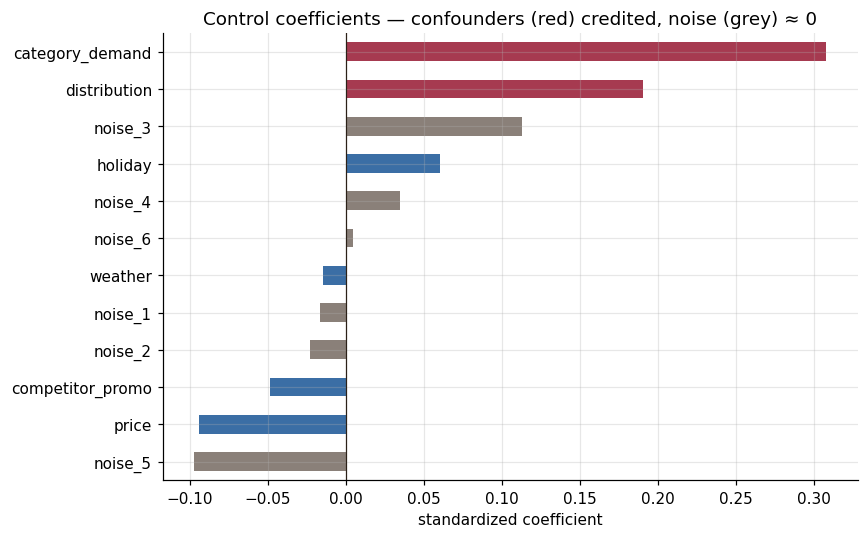

Irrelevant noise controls (should all be ≈ 0):
{'noise_5': np.float64(-0.1), 'noise_2': np.float64(-0.02), 'noise_1': np.float64(-0.02), 'noise_6': np.float64(0.0), 'noise_4': np.float64(0.03), 'noise_3': np.float64(0.11)}


In [14]:
# Two confirmations that the structure is doing its job:
cm = pd.Series(f2.trace.posterior["beta_controls"].mean(dim=["chain", "draw"]).values,
               index=m2.control_names).sort_values()
colors = [BERRY if "demand" in n or "distribution" in n else
          (MUTED if n.startswith("noise") else SKY) for n in cm.index]
fig, ax = plt.subplots(figsize=(8, 5))
cm.plot.barh(ax=ax, color=colors)
ax.axvline(0, color=INK, lw=0.8)
ax.set(title="Control coefficients — confounders (red) credited, noise (grey) ≈ 0",
       xlabel="standardized coefficient")
plt.tight_layout(); plt.show()
print("Irrelevant noise controls (should all be ≈ 0):")
print({n: round(cm[n], 2) for n in cm.index if n.startswith("noise")})

**Recovery.** Adding the confounders and dropping the bad control collapses the
bias — compare the `err` and `in 90% CI` columns of v1 and v2: channels that were
outside their intervals snap back inside, and the large confounded/mediated errors
shrink toward ±15%. The plot shows *why*: the demand confounder is now the
largest-credited control (its signal no longer leaks into media), and the six
`noise_*` controls are correctly shrunk to ≈ 0 by the regularizing prior —
**automatic soft variable selection**, no extra step.

> **Recovery #1 — causal structure is the spec.** The biggest single improvement
> came from classifying controls (confounder / precision / bad control), not from
> more data or tuning.

### Variable selection with a horseshoe prior

The σ=0.5 Normal above is a *soft* regularizer. With many candidate controls you
can instead turn on an explicit **horseshoe** variable-selection prior
(`ModelConfig(control_selection=ControlSelectionConfig(method="horseshoe"))`,
now wired into the model). It shrinks the irrelevant controls aggressively toward
zero while letting real effects escape — and, by construction here, **never
shrinks the confounders** (shrinking a confounder would re-open the back-door).
Refit v2 with it and compare the control coefficients.

In [15]:
v2hs_sc, m2hs = build_model(sc, drop=(sc.notes["mediator"],), roles=roles,
                            selection="horseshoe", target_accept=0.97)
f2hs = timed_fit(m2hs, "v2 + horseshoe")

norm_cm = pd.Series(f2.trace.posterior["beta_controls"].mean(dim=["chain", "draw"]).values,
                    index=m2.control_names)
hs_cm = pd.Series(f2hs.trace.posterior["beta_controls"].mean(dim=["chain", "draw"]).values,
                  index=m2hs.control_names)
cmp = pd.DataFrame({
    "role": [sc.notes["roles"].get(n, "?") for n in norm_cm.index],
    "Normal |coef|": norm_cm.abs().round(3),
    "horseshoe |coef|": hs_cm.abs().round(3),
}).sort_values("role")
display(cmp)
print(f"horseshoe fit divergences: {f2hs.diagnostics['divergences']}  "
      "(it adds a per-control tau/lambda/c2/z hierarchy — slower to sample)")

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

  fit 'v2 + horseshoe' took 11.6s (156 obs, 7 channels, 300 draws x 2 chains, numpyro)


,role,Normal |coef|,horseshoe |coef|
category_demand,confounder,0.308,0.306
distribution,confounder,0.191,0.217
noise_1,irrelevant,0.017,0.004
noise_2,irrelevant,0.023,0.003
noise_3,irrelevant,0.113,0.022
noise_4,irrelevant,0.035,0.021
noise_5,irrelevant,0.097,0.025
noise_6,irrelevant,0.004,0.002
price,precision,0.094,0.057
competitor_promo,precision,0.049,0.019


horseshoe fit divergences: 0  (it adds a per-control tau/lambda/c2/z hierarchy — slower to sample)


Compare the two `|coef|` columns: the horseshoe drives the **irrelevant** controls
markedly closer to zero than the Normal does, while the **confounder** keeps its
full coefficient (exempt from shrinkage). Honest caveat: in this low-SNR world the
horseshoe also shrinks the genuinely-weak *precision* controls — selection shines
when you have a clear haystack of truly-zero candidates, which is why the
framework keeps it **off by default** and reserves it for that case. It also adds
a per-control hierarchy, so it samples slower (see the timing).

But v2 isn't done — and the model **tells you about one remaining problem and
hides the other:**

In [16]:
print("Unidentified (the model SAYS so — contribution CI wider than the estimate):")
print(g2[g2["rel_CI_width"] > 1.5].index.tolist())
print("\nStill biased but CONFIDENT-looking (no diagnostic flags it):")
print(g2[(g2["in 90% CI"] == "✗")].index.tolist(), "— check the 'err' column for TV")
g2[["true", "est", "err", "in 90% CI", "rel_CI_width"]]

Unidentified (the model SAYS so — contribution CI wider than the estimate):
['Radio', 'Print']

Still biased but CONFIDENT-looking (no diagnostic flags it):
['TV'] — check the 'err' column for TV


,true,est,err,in 90% CI,rel_CI_width
channel,,,,,
TV,8948,7319,-18%,✗,0.4
Search,3978,4271,+7%,✓,0.7
Social,3948,4588,+16%,✓,0.7
Display,3090,3644,+18%,✓,1.1
Video,8286,9070,+9%,✓,0.5
Radio,3301,2148,-35%,✓,1.9
Print,2097,1741,-17%,✓,2.2


- **Radio/Print** have intervals wider than their estimates — the honest signal of
  the collinear pair the data can't split (we saw this coming in EDA §1.3).
- **TV** is still mis-estimated (its true value sits outside the interval), yet it
  looks confident — residual confounding from a **noisy** demand proxy that the
  control only partly removes. No observational diagnostic flags it.

Both need randomized evidence.

## Iteration 3 — v3, bring in experiments (Step 8)  🔬

You can't fix the above with more observational modeling. Calibrate with geo-lift
experiments — on the channels the model flagged as **unidentified** (Radio,
Print) and, as standard practice, on the **biggest** channels (TV, Search), since
a confident-but-wrong estimate is invisible to every observational check.

In [17]:
from mmm_framework.calibration import ExperimentCalibrator
from mmm_framework.validation.results import LiftTestResult

unident = g2[g2["rel_CI_width"] > 1.5].index.tolist()
biggest = spend.sum().sort_values(ascending=False).index[:2].tolist()
flagged = unident + [c for c in biggest if c not in unident]
print("Channels to anchor with experiments:", flagged)

period = (str(weeks[0].date()), str(weeks[-1].date()))
lifts = [LiftTestResult(channel=c, test_period=period,
                        measured_lift=float(sc.true_contribution[c]),   # a well-powered lift test
                        lift_se=float(0.12 * sc.true_contribution[c]))
         for c in flagged]
_t0 = time.perf_counter()
with quiet():
    outcome = ExperimentCalibrator(m2, f2).calibrate(
        lifts, refit=True, draws=DRAWS, tune=DRAWS, chains=CHAINS, random_seed=0)
TIMINGS["v3 calibration refit"] = round(time.perf_counter() - _t0, 1)
g3, _ = grade(v2_sc, outcome.model, outcome.results)
g3

Channels to anchor with experiments: ['Radio', 'Print', 'TV', 'Search']


  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

Output()

...

Output()

Output()

Output()

diagnostics: r-hat=1.025  divergences=0


,true,est,err,in 90% CI,rel_CI_width,beta_sd,learning
channel,,,,,,,
TV,8948,7218,-19%,✗,0.4,0.39,weak
Search,3978,4471,+12%,✓,0.6,0.10,moderate
Social,3948,4597,+16%,✓,0.7,0.57,strong
Display,3090,3627,+17%,✓,1.1,0.72,strong
Video,8286,8970,+8%,✓,0.5,0.71,strong
Radio,3301,1789,-46%,✓,2.0,0.10,weak
Print,2097,2041,-3%,✓,2.2,0.07,weak


In [18]:
# What calibration does cleanly: collapse the coefficient uncertainty.
cmp = pd.DataFrame({"v2 beta_sd": g2["beta_sd"], "v3 beta_sd": g3["beta_sd"]})
cmp["anchored"] = ["✓" if c in flagged else "" for c in cmp.index]
display(cmp)
print("Anchored channels' coefficients contract sharply; un-anchored ones don't move.")

,v2 beta_sd,v3 beta_sd,anchored
channel,,,
TV,1.05,0.39,✓
Search,0.44,0.10,✓
Social,0.68,0.57,
Display,0.71,0.72,
Video,0.67,0.71,
Radio,0.68,0.10,✓
Print,0.70,0.07,✓


Anchored channels' coefficients contract sharply; un-anchored ones don't move.


**Experiments identify what data can't.** Compare the `beta_sd` column (v2 → v3):
the anchored channels' coefficient SDs contract **several-fold** (Radio/Print go
from unidentified to pinned); un-anchored channels barely move.

**The honest limit (failure mode that survives even calibration):** TV's
*contribution* barely improves — pinning the coefficient is not enough when the
channel is heavily confounded by a *noisy* proxy, because the lift-to-coefficient
conversion inherits the residual bias. TV needs a **better demand proxy or a
cleaner, TV-specific experiment**; until then its number is provisional.

> **Recovery #2 — experiments identify, but must be designed for the problem.** A
> single lift test pins a *slope*; it does not launder residual confounding out of
> a *contribution*.

*(Step 8 also includes the refutation suite — placebo / negative-control /
random-common-cause / data-subset refits — and prior-sensitivity. See
`tests/synth/realistic_walkthrough.py` and the robustness report; we skip the
refits here to keep the notebook fast.)*

## Step 9 — Communicate with honest uncertainty

The deliverable is a recommendation that states what we know, how well, and on
what evidence — never a bare point estimate.

In [19]:
final = g3.copy()
final["evidence"] = ["lift-anchored" if c in flagged else "observational+DAG" for c in final.index]
final["confidence"] = np.where(final["in 90% CI"] == "✗", "PROVISIONAL (residual bias)",
                       np.where(final["rel_CI_width"] > 1.5, "wide — report as a pair",
                                "usable"))
display(final[["true", "est", "err", "in 90% CI", "evidence", "confidence"]])
print("Budget guidance: shift toward well-identified winners (Search, Video); treat the")
print("collinear pair as one line item; HOLD provisional channels (TV) pending a cleaner experiment.")

,true,est,err,in 90% CI,evidence,confidence
channel,,,,,,
TV,8948,7218,-19%,✗,lift-anchored,PROVISIONAL (residual bias)
Search,3978,4471,+12%,✓,lift-anchored,usable
Social,3948,4597,+16%,✓,observational+DAG,usable
Display,3090,3627,+17%,✓,observational+DAG,usable
Video,8286,8970,+8%,✓,observational+DAG,usable
Radio,3301,1789,-46%,✓,lift-anchored,wide — report as a pair
Print,2097,2041,-3%,✓,lift-anchored,wide — report as a pair


Budget guidance: shift toward well-identified winners (Search, Video); treat the
collinear pair as one line item; HOLD provisional channels (TV) pending a cleaner experiment.


## How much compute did this take?

Real wall-clock from the fits above (fast config: 300 draws × 2 chains, numpyro).
Production runs (≥1000 draws × 4 chains) are several times larger.

In [20]:
budget = pd.Series(TIMINGS, name="seconds")
display(budget.to_frame())
print(f"Total fitting time for the walkthrough: {budget.sum():.0f}s across {len(budget)} fits.")
print()
print("Cost drivers (full study in tests/synth/bench.py / the robustness report):")
print("  • time ∝ observations (weeks × geos) and ∝ draws")
print("  • SUPER-linear in channels (per-channel adstock kernel inside every gradient step)")
print("  • numpyro ≈ 2× faster than the pyMC sampler at equal draws")
print("  • the horseshoe adds a per-control hierarchy (tau, lambda, c2, z) -> slower than Normal")
print("  • the refutation suite (skipped here) refits the whole model ~4×")

,seconds
v1 naive,11.4
v2 causal,10.2
v2 + horseshoe,11.6
v3 calibration refit,9.8


Total fitting time for the walkthrough: 43s across 4 fits.

Cost drivers (full study in tests/synth/bench.py / the robustness report):
  • time ∝ observations (weeks × geos) and ∝ draws
  • SUPER-linear in channels (per-channel adstock kernel inside every gradient step)
  • numpyro ≈ 2× faster than the pyMC sampler at equal draws
  • the horseshoe adds a per-control hierarchy (tau, lambda, c2, z) -> slower than Normal
  • the refutation suite (skipped here) refits the whole model ~4×


---
# Part 3 — Failure-mode quick reference

| failure mode | EDA signal (Part 1) | what catches it in modeling | recovery |
|---|---|---|---|
| **Unobserved confounding** | spend correlates with demand (§1.5) | *nothing* observational — converges & passes PPC | include the confounder (don't shrink); anchor with a lift test |
| **Bad control (mediator)** | a control is downstream of media (§1.6) | contribution drops vs. expectation; DAG review | **drop** the post-treatment variable |
| **Collinearity** | \|corr\|>0.9 / VIF>10 (§1.3) | huge contribution CIs; sometimes divergences | group the channels, or anchor one with an experiment |
| **Always-on / weak** | low CoV (§1.2) | prior-dominated / wide CI | experiment, or report a wide interval honestly |
| **Spend outliers** | max ≫ median (§1.4) | attenuated effects; 0% CI coverage | cap/winsorize; normalize by a percentile |
| **Structural break** | level shift in KPI (§1.1) | poor PPC on the break window | dummy or piecewise trend |
| **Functional-form misspec** | (not visible in EDA) | wrong-shape PPC; see robustness report | richer adstock/saturation; experiments |

**Meta-lessons.** (1) Modeling is iterative — the DAG drove v2, the model's own
uncertainty drove v3. (2) Diagnostics check the sampler, not the truth. (3) Causal
structure is the spec. (4) Let the model tell you what it can't do — wide
intervals route you to the right experiment. (5) Experiments identify, but must be
designed for the channel you're trying to rescue.

**Reproduce / go deeper:** `technical-docs/mmm-modeling-walkthrough.md`,
`technical-docs/mmm-robustness-report.md`, `tests/synth/`.